In [2]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Load built-in Titanic dataset
df = sns.load_dataset('titanic')

# Find missing values
print("Missing values before cleaning:\n", df.isnull().sum())

# Fill 'age' with its median
df['age'] = df['age'].fillna(df['age'].median())

# Fill 'embarked' with its mode (most common port)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

Missing values before cleaning:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [3]:
# Initialize the label encoder
le_sex = LabelEncoder()
le_embarked = LabelEncoder()

# Fit and transform the text columns into numeric columns
df['sex'] = le_sex.fit_transform(df['sex'])
df['embarked'] = le_embarked.fit_transform(df['embarked'].astype(str))

print(df[['sex', 'embarked']].head())

   sex  embarked
0    1         2
1    0         0
2    0         2
3    0         2
4    1         2


In [4]:
scaler = StandardScaler()

# Apply standard scaling to Age and Fare
df[['age', 'fare']] = scaler.fit_transform(df[['age', 'fare']])

print(df[['age', 'fare']].head())

        age      fare
0 -0.565736 -0.502445
1  0.663861  0.786845
2 -0.258337 -0.488854
3  0.433312  0.420730
4  0.433312 -0.486337


In [5]:
# Drop non-numeric, redundant, or target columns to isolate features (X)
X = df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
y = df['survived']

# Perform 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the matrix structures
print(f"X_train Shape: {X_train.shape} | X_test Shape: {X_test.shape}")
print(f"y_train Shape: {y_train.shape} | y_test Shape: {y_test.shape}")

X_train Shape: (712, 7) | X_test Shape: (179, 7)
y_train Shape: (712,) | y_test Shape: (179,)


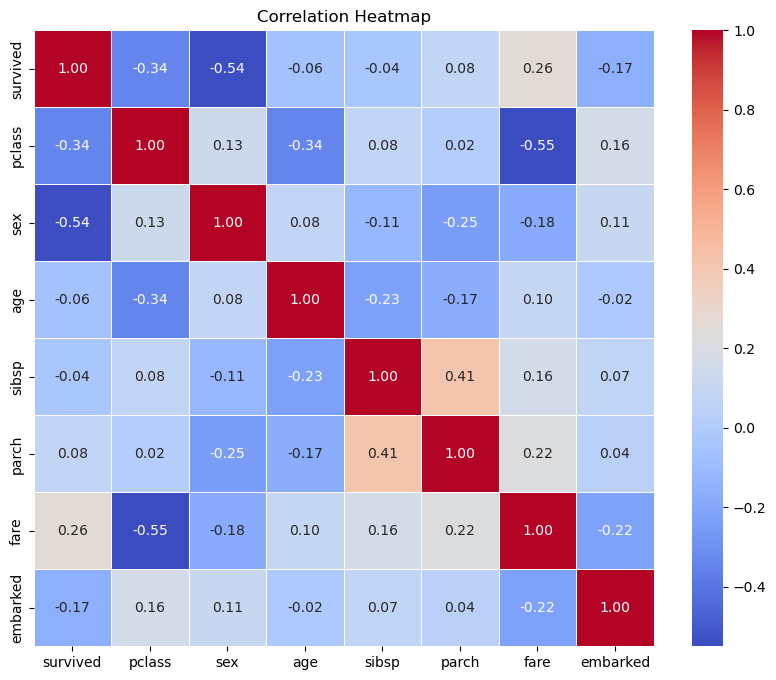


Top 5 features strongly correlated with Survival:
 ['sex', 'pclass', 'fare', 'embarked', 'parch']


In [6]:
import matplotlib.pyplot as plt

# Select only numeric values for correlation analysis
numeric_df = df.select_dtypes(include=['float64', 'int64', 'int32'])

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Identify top 5 features most correlated with the target variable ('survived')
# We look at absolute values because strong negative correlation is just as valuable as positive
top_5_features = corr_matrix['survived'].abs().sort_values(ascending=False).index[1:6]
print("\nTop 5 features strongly correlated with Survival:\n", list(top_5_features))